Problem Statement:

The project title is "Customer Segmentation and Purchase Behaviour Prediction" so basically not all customers behaves same way as others. Some customer buys frequently and some buy, some are leaving. The company might waste their money by thinking all customer as same.



Objective:

To segment customers based on purchasing behavior using clustering techniques and predict future customer actions using multiple machine learning models, followed by performance comparison to identify the most effective model.

It's a clustering and classification problem.

Dataset: https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

In [2]:
import pandas as pd
data = pd.read_csv("Mall_Customers.csv")
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
data.shape

(200, 5)

In [3]:
data.isnull().sum()

,0
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [5]:
data.duplicated().sum()

np.int64(0)

In [8]:
#Checing the data type of the column
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


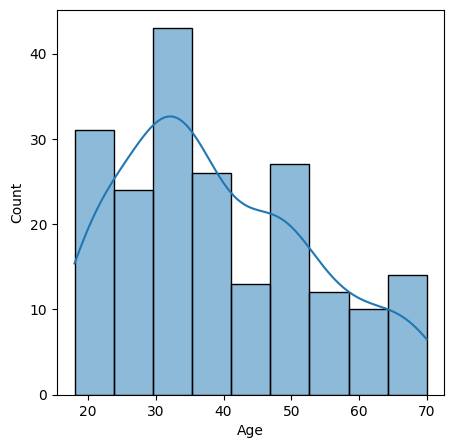

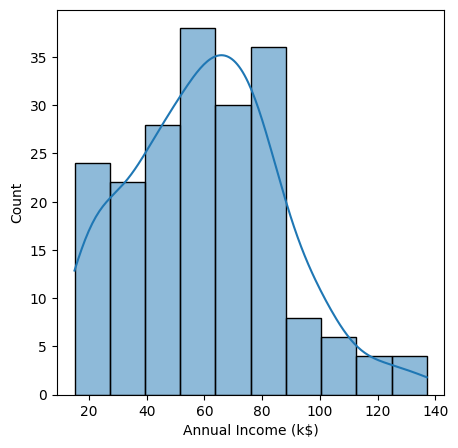

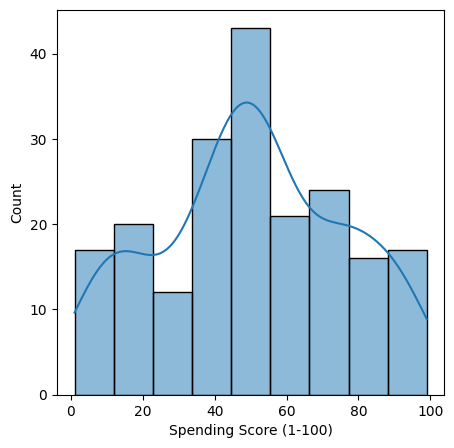

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
#Checking the distribution
numeric_cols = data.select_dtypes(include='number').columns

for col in numeric_cols[1:]:
    plt.figure(figsize=(5,5))
    sns.histplot(data=data, x=col, kde=True)
    plt.show()

<Axes: >

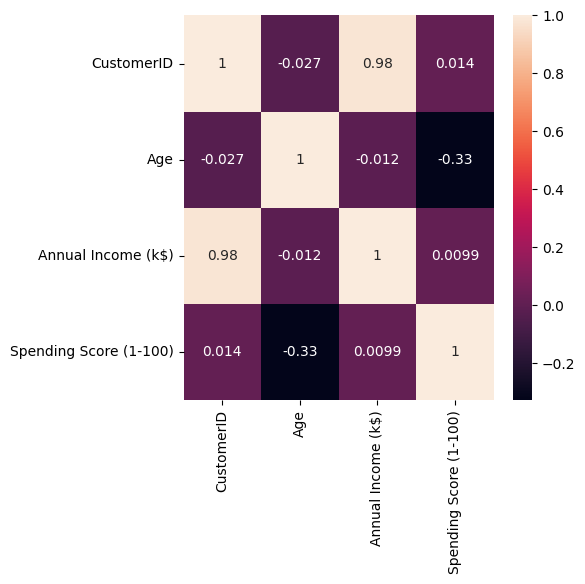

In [16]:
from numpy._core import numeric
#Checking the correlations
correlation = data.corr(numeric_only=True)
plt.figure(figsize=(5,5))
sns.heatmap(correlation, annot=True)

In [17]:
correlation['Annual Income (k$)']

,Annual Income (k$)
CustomerID,0.977548
Age,-0.012398
Annual Income (k$),1.000000
Spending Score (1-100),0.009903


In [18]:
correlation['Spending Score (1-100)']

,Spending Score (1-100)
CustomerID,0.013835
Age,-0.327227
Annual Income (k$),0.009903
Spending Score (1-100),1.000000


Selecting relevant features of dataset for training period

In [31]:
x = data.iloc[:,[3,4]].values
print(x)

[[ 15  39]
 [ 15  81]
 [ 16   6]
 [ 16  77]
 [ 17  40]
 [ 17  76]
 [ 18   6]
 [ 18  94]
 [ 19   3]
 [ 19  72]
 [ 19  14]
 [ 19  99]
 [ 20  15]
 [ 20  77]
 [ 20  13]
 [ 20  79]
 [ 21  35]
 [ 21  66]
 [ 23  29]
 [ 23  98]
 [ 24  35]
 [ 24  73]
 [ 25   5]
 [ 25  73]
 [ 28  14]
 [ 28  82]
 [ 28  32]
 [ 28  61]
 [ 29  31]
 [ 29  87]
 [ 30   4]
 [ 30  73]
 [ 33   4]
 [ 33  92]
 [ 33  14]
 [ 33  81]
 [ 34  17]
 [ 34  73]
 [ 37  26]
 [ 37  75]
 [ 38  35]
 [ 38  92]
 [ 39  36]
 [ 39  61]
 [ 39  28]
 [ 39  65]
 [ 40  55]
 [ 40  47]
 [ 40  42]
 [ 40  42]
 [ 42  52]
 [ 42  60]
 [ 43  54]
 [ 43  60]
 [ 43  45]
 [ 43  41]
 [ 44  50]
 [ 44  46]
 [ 46  51]
 [ 46  46]
 [ 46  56]
 [ 46  55]
 [ 47  52]
 [ 47  59]
 [ 48  51]
 [ 48  59]
 [ 48  50]
 [ 48  48]
 [ 48  59]
 [ 48  47]
 [ 49  55]
 [ 49  42]
 [ 50  49]
 [ 50  56]
 [ 54  47]
 [ 54  54]
 [ 54  53]
 [ 54  48]
 [ 54  52]
 [ 54  42]
 [ 54  51]
 [ 54  55]
 [ 54  41]
 [ 54  44]
 [ 54  57]
 [ 54  46]
 [ 57  58]
 [ 57  55]
 [ 58  60]
 [ 58  46]
 [ 59  55]

Model Building
- Choosing KMean algorithm for clustering the customers based on their Annual Income and SPending Score.
- Choosing a correct value of K in KMeans for this dataset by using WCSS (Within Clusters Sum of Square)

In [37]:
from sklearn.cluster import KMeans

wscc = []
for i in range(1,11):
  kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
  kmeans.fit(x)
  wscc.append(kmeans.inertia_)


Text(0, 0.5, 'wscc')

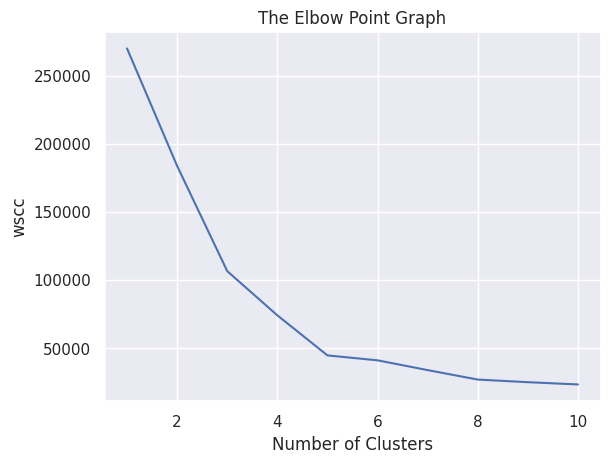

In [38]:
#Plotting an Elbow Graph

sns.set()
plt.plot(range(1,11), wscc)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('wscc')

Observation:

By looking at the elbow graph we can see that their are 2 elbow points in the graph that is 3 and 5, but if we see that after 5 their is no sharp elbow point in the graph.

Hence, it will be safe to consider k as 5 for optimal clustering within the dataset.

In [41]:
kmean = KMeans(n_clusters=5, init='k-means++', random_state=42)
y = kmean.fit_predict(x)
y

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

Let's visualize the clusters

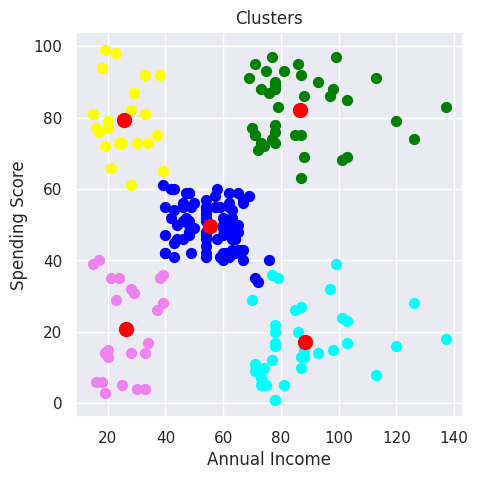

In [47]:
plt.figure(figsize=(5,5))
plt.scatter(x[y==0,0], x[y==0,1], s=50, c='blue', label='Cluster 1')
plt.scatter(x[y==1,0], x[y==1,1], s=50, c='green', label='Cluster 2')
plt.scatter(x[y==2,0], x[y==2,1], s=50, c='yellow', label='Cluster 3')
plt.scatter(x[y==3,0], x[y==3,1], s=50, c='cyan', label='Cluster 4')
plt.scatter(x[y==4,0], x[y==4,1], s=50, c='violet', label='Cluster 5')

plt.scatter(kmean.cluster_centers_[:,0], kmean.cluster_centers_[:,1], s=100, c='red', label='Centroids')
plt.title('Clusters')
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.show()

Observation:

The clustering analysis based on Annual Income and Spending Score successfully identified five distinct customer segments, each representing different purchasing behaviors and economic profiles.

1. High Income – High Spending (Green Cluster)
Most valuable customers
High purchasing power + high engagement

Suggestion: Target with premium products and offer loyalty rewards

2. High Income – Low Spending (Cyan Cluster)
Rich but not spending much

Suggestion: Use personalized marketing and
provide discounts or recommendations

3. Low Income – High Spending (Yellow Cluster)
Spend more despite lower income

Suggestion: Focus on retention and offer budget-friendly deals

4. Low Income – Low Spending (Pink Cluster)
Least valuable customers

Suggestion: Minimal marketing spend and focus only if cost-effective

5. Medium Income – Medium Spending (Blue Cluster)
Average customers (majority group)

Suggestion: Upsell strategies and convert into high-value customers



Conclusion:

K-Means clustering effectively segmented customers into meaningful groups, enabling targeted marketing strategies and better resource allocation for improved business performance.